In [1]:
from classy_nu import Class
from classy import Class as Class_LCDM
import numpy as np

In [2]:
SIDR_params = {
    'output': 'tCl,pCl,lCl,mPk',
    'omega_cdm': 0.12,
    'omega_b': 0.022,
    'h': 0.67,
    'ln10^{10}A_s': 3.05,
    'n_s': 0.965,
    'tau_reio': 0.06,
    'lensing': 'yes',
    'r': 0.1,
    'm_ncdm_interacting': 0.1,
    'log10G_eff_ncdm_interacting': 12,
    'deg_ncdm_interacting': 3,
    'k_pivot': 0.05,	  
    'N_ncdm_interacting' : 1.0,
    'ncdm_fluid_approximation': 3.0,
    'modes': 's,t',
    'N_ur': 0,
    'P_k_max_h/Mpc': 1.0
}

lcdm_params = {
    'output': 'tCl,pCl,lCl,mPk',
    'omega_cdm': 0.12,
    'omega_b': 0.022,
    'h': 0.67,
    'ln10^{10}A_s': 3.05,
    'n_s': 0.965,
    'tau_reio': 0.06,
    'lensing': 'yes'
}

class_lcdm = Class_LCDM()
class_lcdm.set(lcdm_params)
class_lcdm.compute()

class_sidr = Class()
class_sidr.set(SIDR_params)
class_sidr.compute()



/tmp/ipykernel_999082/3363199717.py:11: RuntimeWarning: invalid value encountered in divide
  percent_difference = 100 * (clls_sidr - clls) / clls


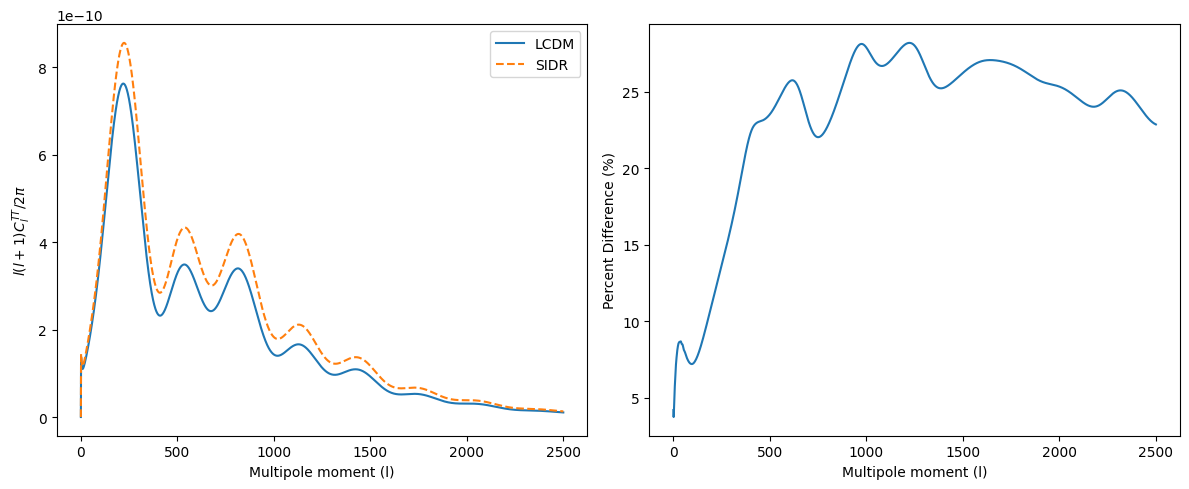

In [3]:
import matplotlib.pyplot as plt

cls_lcdm = class_lcdm.lensed_cl(2500)
clls = cls_lcdm['tt'][1:]
ells = cls_lcdm['ell'][1:]

class_sidr = class_sidr.lensed_cl(2500)
clls_sidr = class_sidr['tt'][1:]
ells_sidr = class_sidr['ell'][1:]

percent_difference = 100 * (clls_sidr - clls) / clls

fig,ax = plt.subplots(1,2, figsize=(12,5))
ax[0].plot(ells, clls * ells * (ells + 1) / (2 * 3.14159), label='LCDM')
ax[0].plot(ells_sidr, clls_sidr * ells_sidr * (ells_sidr + 1) / (2 * 3.14159), label='SIDR', linestyle='--')
ax[0].set_xlabel('Multipole moment (l)')
ax[1].plot(ells, percent_difference, label='Percent Difference')
ax[1].set_xlabel('Multipole moment (l)')
ax[1].set_ylabel('Percent Difference (%)')
#ax[1].set_ylim(-0.05, 0.05)
ax[0].set_ylabel(r'$l(l+1)C_l^{TT}/2\pi$')
ax[0].legend()
plt.tight_layout()
plt.show()

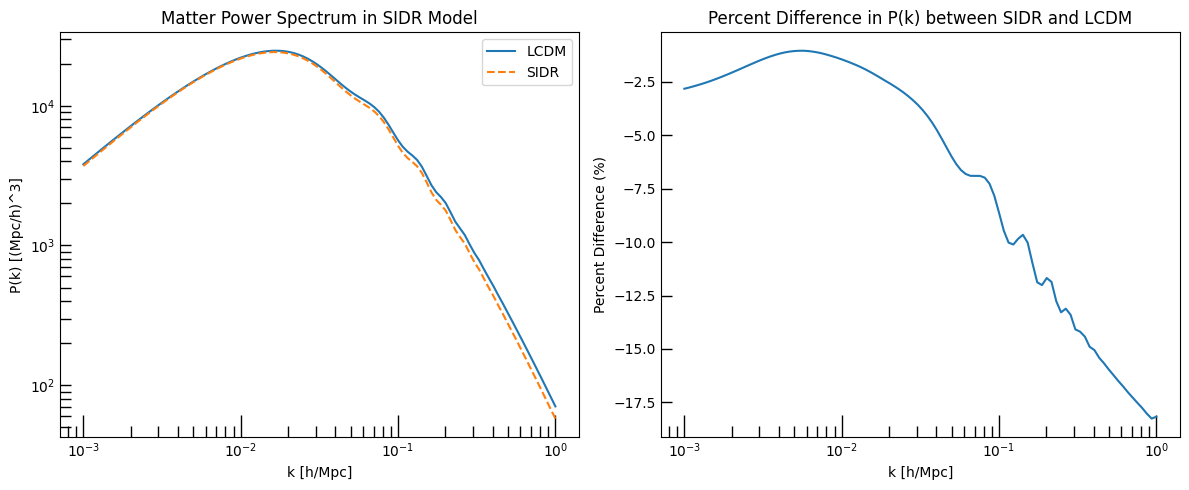

In [4]:
SIDR_params = {
   'output': 'tCl,pCl,lCl,mPk',
    'omega_cdm': 0.12,
    'omega_b': 0.022,
    'h': 0.67,
    'ln10^{10}A_s': 3.05,
    'n_s': 0.965,
    'tau_reio': 0.06,
    'lensing': 'yes',
    'r': 0.1,
    'm_ncdm_interacting': 0.1,
    'log10G_eff_ncdm_interacting': 12,
    'deg_ncdm_interacting': 3,
    'k_pivot': 0.05,	  
    'N_ncdm_interacting' : 1.0,
    'ncdm_fluid_approximation': 3.0,
    'modes': 's,t',
    'N_ur': 0,
    'P_k_max_h/Mpc': 1.0
}
class_sidr = Class()
class_sidr.set(SIDR_params)
class_sidr.compute()

k_values = np.logspace(-3, 0, 100)
k_class = k_values * 0.67
P_k_sidr = np.array([class_sidr.pk(k, 0.0) for k in k_class])
P_k_LCDM = np.array([class_lcdm.pk(k, 0.0) for k in k_class])

P_k_sidr = P_k_sidr * 0.67**3
P_k_LCDM = P_k_LCDM * 0.67**3

percent_differrence_pk = 100 * (P_k_sidr - P_k_LCDM) / P_k_LCDM

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(k_values, P_k_LCDM, label='LCDM')
ax[0].plot(k_values, P_k_sidr, linestyle='--', label='SIDR')
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlabel('k [h/Mpc]')
ax[0].set_ylabel('P(k) [(Mpc/h)^3]')
ax[0].set_title('Matter Power Spectrum in SIDR Model')
ax[0].legend()

# Make axis lines appear inside and bigger
# Make axis lines appear inside and bigger
ax[0].tick_params(axis='both', which='both', direction='in', length=8, width=1)
ax[0].tick_params(axis='x', which='major', length=16, width=1)  # Longer ticks for major x-ticks (1,10,100,...)


ax[1].plot(k_values, percent_differrence_pk)
ax[1].set_xscale('log')
ax[1].set_xlabel('k [h/Mpc]')
ax[1].set_ylabel('Percent Difference (%)')
ax[1].set_title('Percent Difference in P(k) between SIDR and LCDM')
# Make axis lines appear inside and bigger
ax[1].tick_params(axis='both', which='both', direction='in', length=8, width=1)
ax[1].tick_params(axis='x', which='major', length=16, width=1)  # Longer ticks for major x-ticks (1,10,100,...)
plt.tight_layout()


plt.show()

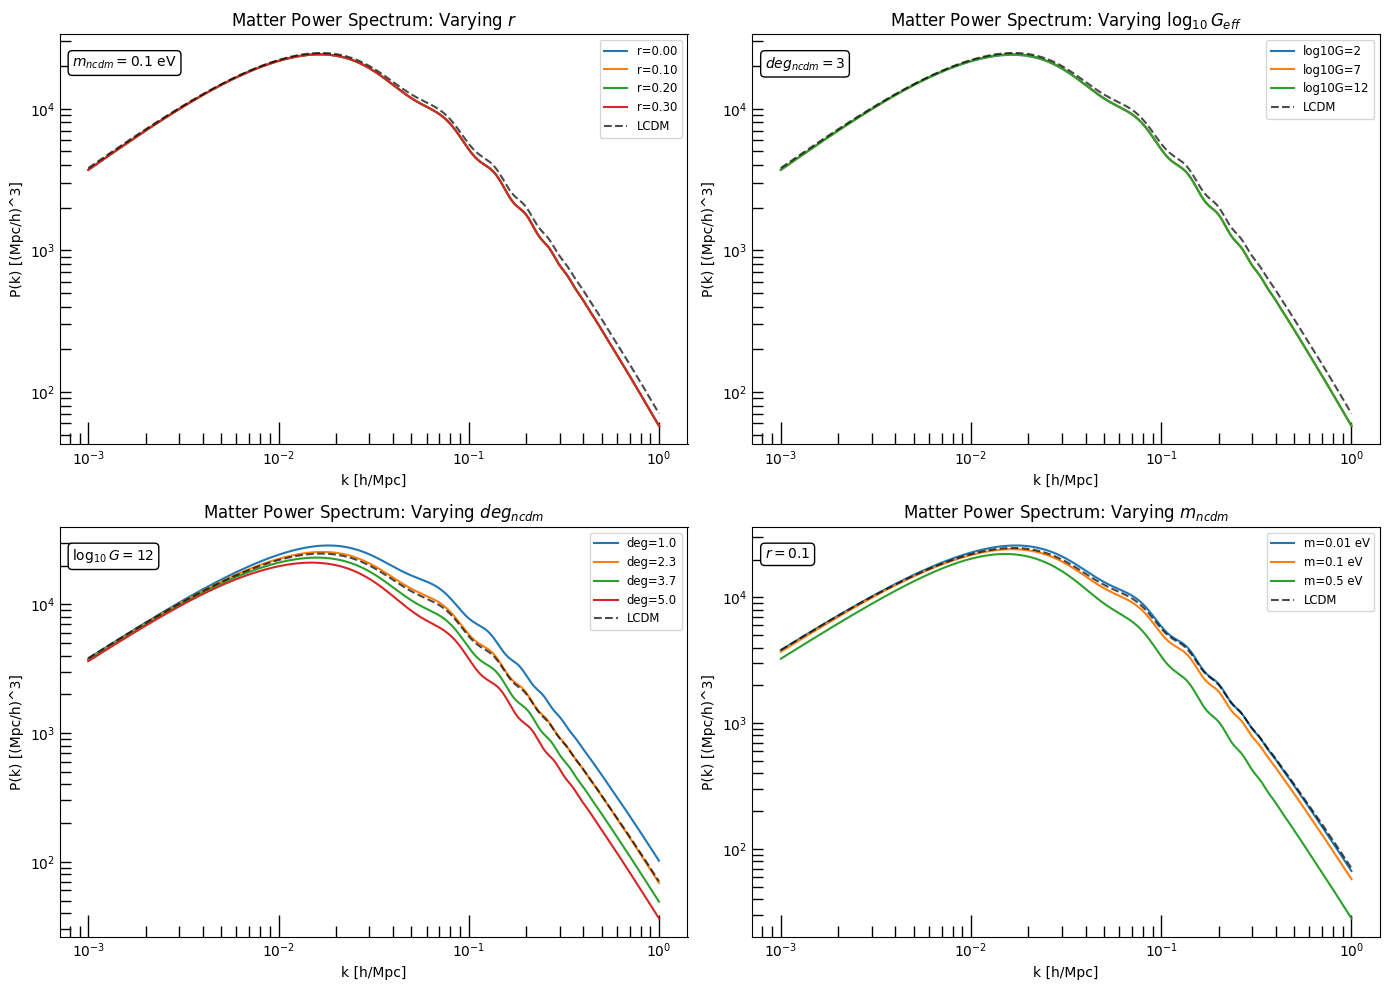

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from classy_nu import Class

# --- 1. SETTINGS & BASELINE ---
k_values = np.logspace(-3, 0, 1000)
h_fixed = 0.67

# Baseline SIDR defaults
defaults = {
    'output': 'tCl,pCl,lCl,mPk',
    'omega_cdm': 0.12,
    'omega_b': 0.022,
    'h': h_fixed,
    'ln10^{10}A_s': 3.05,
    'n_s': 0.965,
    'tau_reio': 0.06,
    'lensing': 'yes',
    'r': 0.1,
    'm_ncdm_interacting': 0.1,
    'log10G_eff_ncdm_interacting': 12,
    'deg_ncdm_interacting': 3,
    'N_ncdm_interacting' : 1.0,
    'ncdm_fluid_approximation': 3.0,
    'modes': 's,t',
    'N_ur': 0,
    'P_k_max_h/Mpc': 1.0
}

def get_data(override_dict):
    """Safely runs SIDR model with specific overrides."""
    cosmo = Class()
    full_params = defaults.copy()
    full_params.update(override_dict)
    cosmo.set(full_params)
    cosmo.compute()
    
    k_range = k_values * h_fixed
    pk = np.array([cosmo.pk(k, 0.0) for k in k_range]) * h_fixed**3
    
    cosmo.struct_cleanup()
    cosmo.empty()
    return pk

def get_lcdm_pk():
    """Computes the standard LCDM baseline."""
    lcdm = Class()
    lcdm.set({
        'output': 'mPk',
        'omega_cdm': 0.12,
        'omega_b': 0.022,
        'h': h_fixed,
        'ln10^{10}A_s': 3.05,
        'n_s': 0.965,
        'tau_reio': 0.06
    })
    lcdm.compute()
    k_range = k_values * h_fixed
    pk = np.array([lcdm.pk(k, 0.0) for k in k_range]) * h_fixed**3
    lcdm.struct_cleanup()
    lcdm.empty()
    return pk

# Pre-compute LCDM once
pk_lcdm = get_lcdm_pk()

# --- 2. PLOTTING ---
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
box_props = dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)

# Parameter Ranges
r_values = np.linspace(0, 0.3, 4)
log10G_values = [2, 7, 12]
deg_values = np.linspace(1, 5, 4)
m_values = [0.01, 0.1, 0.5]

# Function to add LCDM and styling to an axis
def style_panel(a, title, text_content):
    a.plot(k_values, pk_lcdm, label='LCDM', color='black', linestyle='--', alpha=0.7, lw=1.5)
    a.set_title(title)
    a.text(0.02, 0.95, text_content, transform=a.transAxes, bbox=box_props, verticalalignment='top')
    a.set_xscale('log')
    a.set_yscale('log')
    a.set_xlabel('k [h/Mpc]')
    a.set_ylabel('P(k) [(Mpc/h)^3]')
    a.tick_params(axis='both', which='both', direction='in', length=8, width=1)
    a.tick_params(axis='x', which='major', length=16, width=1)
    a.legend(fontsize='small')

# Panel 0,0: Varying r
for val in r_values:
    pk = get_data({'r': val})
    ax[0, 0].plot(k_values, pk, label=f'r={val:.2f}')
style_panel(ax[0, 0], 'Matter Power Spectrum: Varying $r$', r'$m_{ncdm}=0.1$ eV')

# Panel 0,1: Varying log10G
for val in log10G_values:
    pk = get_data({'log10G_eff_ncdm_interacting': val})
    ax[0, 1].plot(k_values, pk, label=f'log10G={val}')
style_panel(ax[0, 1], r'Matter Power Spectrum: Varying $\log_{10}G_{eff}$', r'$deg_{ncdm}=3$')

# Panel 1,0: Varying deg_ncdm
for val in deg_values:
    pk = get_data({'deg_ncdm_interacting': val})
    ax[1, 0].plot(k_values, pk, label=f'deg={val:.1f}')
style_panel(ax[1, 0], r'Matter Power Spectrum: Varying $deg_{ncdm}$', r'$\log_{10}G=12$')

# Panel 1,1: Varying m_ncdm
for val in m_values:
    pk = get_data({'m_ncdm_interacting': val})
    ax[1, 1].plot(k_values, pk, label=f'm={val} eV')
style_panel(ax[1, 1], r'Matter Power Spectrum: Varying $m_{ncdm}$', r'$r=0.1$')

plt.tight_layout()
plt.show()

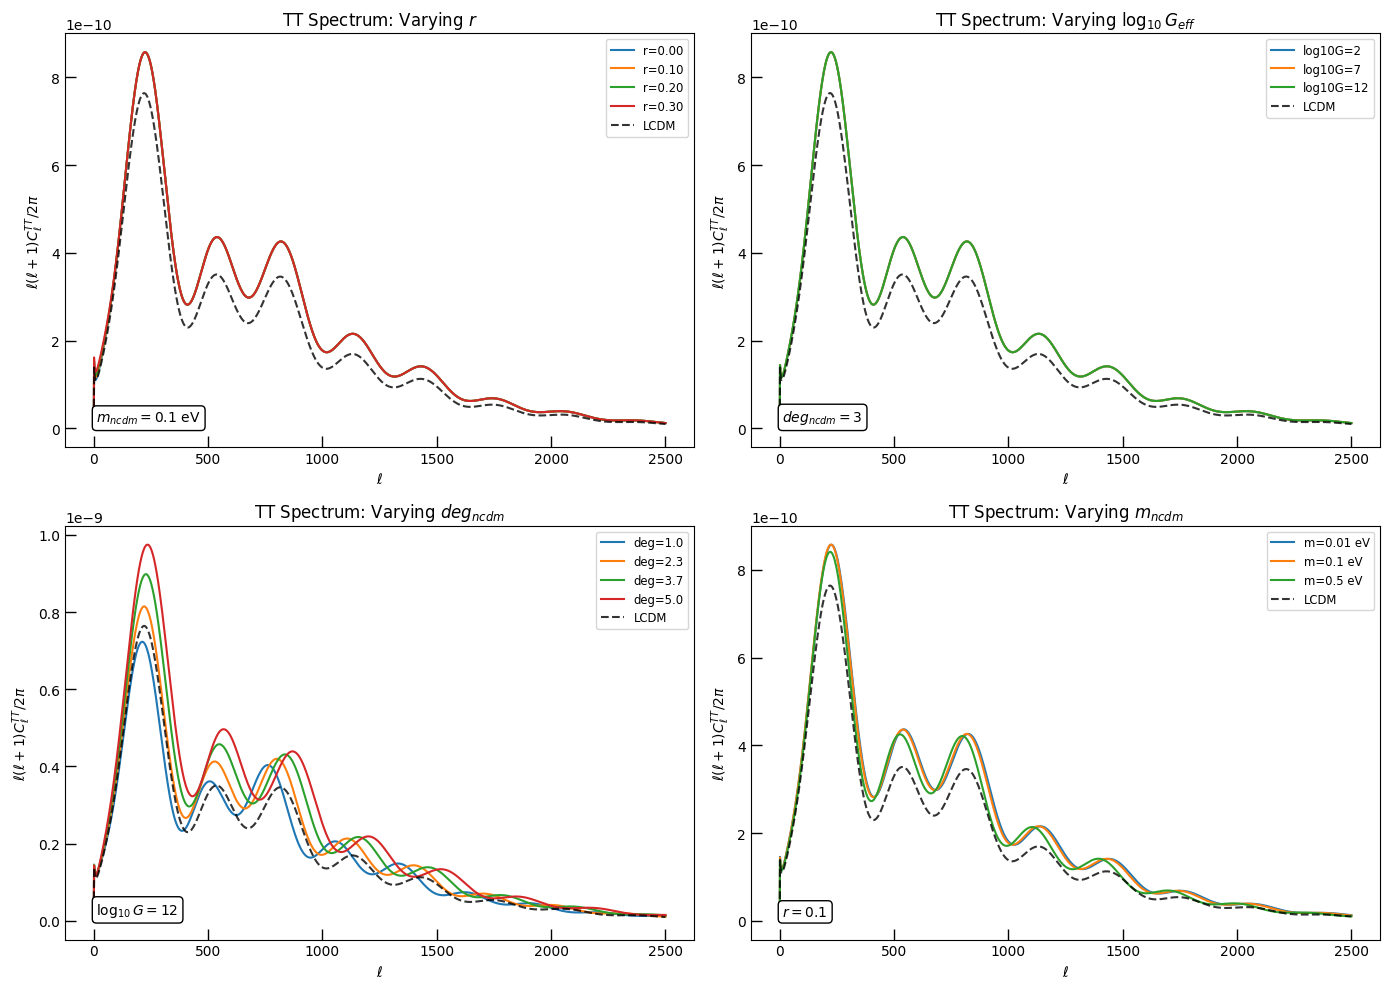

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from classy_nu import Class

# --- 1. SETTINGS & BASELINE ---
l_max = 2500
h_fixed = 0.67

# Baseline SIDR defaults
defaults = {
    'output': 'tCl,pCl,lCl,mPk',
    'omega_cdm': 0.12,
    'omega_b': 0.022,
    'h': h_fixed,
    'ln10^{10}A_s': 3.05,
    'n_s': 0.965,
    'tau_reio': 0.06,
    'lensing': 'yes',
    'r': 0.1,
    'm_ncdm_interacting': 0.1,
    'log10G_eff_ncdm_interacting': 12,
    'deg_ncdm_interacting': 3,
    'N_ncdm_interacting' : 1.0,
    'ncdm_fluid_approximation': 3.0,
    'modes': 's,t',
    'N_ur': 0
}

def get_cl_data(override_dict):
    """Safely runs SIDR model and returns Dl_TT."""
    cosmo = Class()
    full_params = defaults.copy()
    full_params.update(override_dict)
    cosmo.set(full_params)
    cosmo.compute()
    
    cls = cosmo.raw_cl(l_max)
    ells = cls['ell']
    # Convert Cl to Dl: l(l+1)Cl / 2pi
    # Note: CLASS returns raw Cls. Dl = l*(l+1)*Cl/(2*pi) * 1e12 for microKelvin^2 
    # but usually we keep it in dimensionless or consistent units.
    dl_tt = ells * (ells + 1) * cls['tt'] / (2 * np.pi)
    
    cosmo.struct_cleanup()
    cosmo.empty()
    return ells, dl_tt

def get_lcdm_cl():
    """Computes standard LCDM Dl_TT."""
    lcdm = Class()
    lcdm.set({
        'output': 'tCl',
        'h': h_fixed,
        'omega_cdm': 0.12,
        'omega_b': 0.022,
        'ln10^{10}A_s': 3.05,
        'n_s': 0.965,
        'tau_reio': 0.06
    })
    lcdm.compute()
    cls = lcdm.raw_cl(l_max)
    ells = cls['ell']
    dl_tt = ells * (ells + 1) * cls['tt'] / (2 * np.pi)
    lcdm.struct_cleanup()
    lcdm.empty()
    return ells, dl_tt

# Pre-compute LCDM baseline
ells_lcdm, dl_lcdm = get_lcdm_cl()

# --- 2. PLOTTING ---
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
box_props = dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1)

# Parameter Ranges
r_values = np.linspace(0, 0.3, 4)
log10G_values = [2, 7, 12]
deg_values = np.linspace(1, 5, 4)
m_values = [0.01, 0.1, 0.5]

def style_panel(a, title, text_content):
    a.plot(ells_lcdm, dl_lcdm, label='LCDM', color='black', linestyle='--', alpha=0.8)
    a.set_title(title)
    a.set_xlabel(r'$\ell$')
    a.set_ylabel(r'$\ell(\ell+1)C_\ell^{TT} / 2\pi$')
    a.text(0.05, 0.05, text_content, transform=a.transAxes, bbox=box_props, verticalalignment='bottom')
    a.tick_params(axis='both', which='both', direction='in', length=8, width=1)
    a.legend(fontsize='small', loc='upper right')

# Panel 0,0: r
for val in r_values:
    ells, dl = get_cl_data({'r': val})
    ax[0, 0].plot(ells, dl, label=f'r={val:.2f}')
style_panel(ax[0, 0], 'TT Spectrum: Varying $r$', r'$m_{ncdm}=0.1$ eV')

# Panel 0,1: log10G
for val in log10G_values:
    ells, dl = get_cl_data({'log10G_eff_ncdm_interacting': val})
    ax[0, 1].plot(ells, dl, label=f'log10G={val}')
style_panel(ax[0, 1], r'TT Spectrum: Varying $\log_{10}G_{eff}$', r'$deg_{ncdm}=3$')

# Panel 1,0: deg_ncdm
for val in deg_values:
    ells, dl = get_cl_data({'deg_ncdm_interacting': val})
    ax[1, 0].plot(ells, dl, label=f'deg={val:.1f}')
style_panel(ax[1, 0], r'TT Spectrum: Varying $deg_{ncdm}$', r'$\log_{10}G=12$')

# Panel 1,1: m_ncdm
for val in m_values:
    ells, dl = get_cl_data({'m_ncdm_interacting': val})
    ax[1, 1].plot(ells, dl, label=f'm={val} eV')
style_panel(ax[1, 1], r'TT Spectrum: Varying $m_{ncdm}$', r'$r=0.1$')

plt.tight_layout()
plt.show()